# Assignment 10 - Structural Loads and V-n Diagram


## Objective
The objective of this assignment is to define the structural operating envelope (V-n diagram) accounting for detailed atmospheric modeling, estimate the inertial and aerodynamic loads on the fuselage for a balanced aircraft trim case, and determine the wing box load distribution.

## Description
Develop a mathematical model (using MATLAB or Python) to compute the limit load factors and generate the V-n diagram using a dynamically calculated International Standard Atmosphere (ISA) model. In addition, develop a solver for the fuselage loads that balances the full aircraft weight against aerodynamic lift. Finally, resolve the aerodynamic loads over the wing elastic axis to calculate shear force and bending moment diagrams for the wing box.

## Tasks

### 1. Dynamic V-n Diagram (Mach vs. Load Factor)
Construct the V-n diagram for your aircraft (e.g., F/A-18).
* Implement an International Standard Atmosphere (ISA) model to dynamically calculate static pressure ($p$) as a function of geometric altitude ($h$) for both the troposphere and tropopause.
* Map dynamic pressure ($q$) directly from Mach number ($M$) to establish the load factor limits ($n_{stall}$).
* Close the low-speed side of the envelope using a strict minimum-speed placard.
* Consider the positive and negative structural limits ($n_{max}$ and $n_{min}$).
* **Plot:** Plot the maneuver V-n diagram overlaid or side-by-side with appropriate structural and aerodynamic limit curves.

### 2. Fuselage Loads (Balanced Assembly Case)
Estimate the longitudinal load distribution along the fuselage for a critical pull-up maneuver point on the V-n diagram (e.g., $n_{z} = 7.5$).
* Distribute the fuselage shell structural mass (e.g., trapezoidal distribution centered around the wing carry-through) from nose to tail.
* Incorporate concentrated system/point masses (e.g., Radar, Nose Gear, Avionics, Wing, Engines, etc.) mapped to specific Fuselage Stations (FS).
* Implement a Global Trim Solver to find the balance of aerodynamic lift at the wing ($L_w$) and tail ($L_t$) required to counteract the total inertial weight at $n_z$.
* Integrate the distributed structural weight, point masses, and balancing aerodynamic forces from the nose aftwards to calculate shear force ($V$) and bending moment ($M$).
* **Plot:** Generate professional, dual-axis shear force and bending moment diagrams along the fuselage length, indicating key stations such as the CG and aerodynamic centers.
* **Output:** Identify the location and magnitude of the peak bending moment and shear force on the structural shell.

### 3. Wing Box Load Distribution
Establish the external aerodynamic loads on the multi-spar wing box during a critical maneuver case.
* Apply Schrenk's approximation by combining an elliptical lift distribution with a planform-proportional lift distribution.
* Resolve the aerodynamic loads perpendicular to the elastic axis, accounting for the quarter-chord sweep angle.
* Utilize numeric integration (e.g., cumulative trapezoidal rule) starting from the wing tip to find internal Shear Force ($V$) and Bending Moment ($M$).
* **Plot:** Generate a stacked plot showing the lift distribution ($lbf/in$), Shear Force ($lbf$), and Bending Moment ($lbf-in$) along the spanwise coordinate ($y$).

## Deliverables
Submit a presentation slide deck (e.g., PowerPoint or PDF) via the course portal. The presentation must contain:
1. **Dynamic V-n Diagram:** The finalized V-n plot mapping Mach to load factor, with limit lines.
2. **Fuselage Load Diagrams:** Shear and bending moment plots indicating maximum values and assembly locations for the balanced case.
3. **Wing Box Load Diagrams:** Lift distribution, shear force, and bending moment mapped along the true spanwise coordinate.
4. **Summary & Discussion:** Discuss how the peak loads impact your structural sizing from previous analyses, and the impact of the dynamically calculated ISA static pressure on the flight envelope.


# F/A-18 V-n Diagram (Mach vs. Load Factor) - ISA Pressure

This notebook generates the flight envelope for an F/A-18 Hornet. It features a dynamically calculated International Standard Atmosphere (ISA) model to determine static pressure at any given altitude, rather than relying on hardcoded pressure values. The low-speed side is closed using a strict minimum-speed placard.

## Mathematical Foundation

### 1. International Standard Atmosphere (ISA)
Pressure ($p$) is calculated based on geometric altitude ($h$ in meters):

**Troposphere ($h \le 11,000$ m):**
$$p = p_0 \cdot \left(1 + \frac{L \cdot h}{T_0}\right)^{\frac{-g}{R \cdot L}}$$

**Tropopause ($11,000 < h \le 20,000$ m):**
$$p = p_{11} \cdot \exp\left(\frac{-g \cdot (h - 11000)}{R \cdot T_{11}}\right)$$

### 2. Dynamic Pressure & Stall
Dynamic pressure is mapped from Mach ($M$): $q = \frac{1}{2} \gamma p M^2$. 
The maximum load factor before stall is:
$$n_{stall} = \frac{\gamma p M^2 C_L}{2 (W/S)}$$

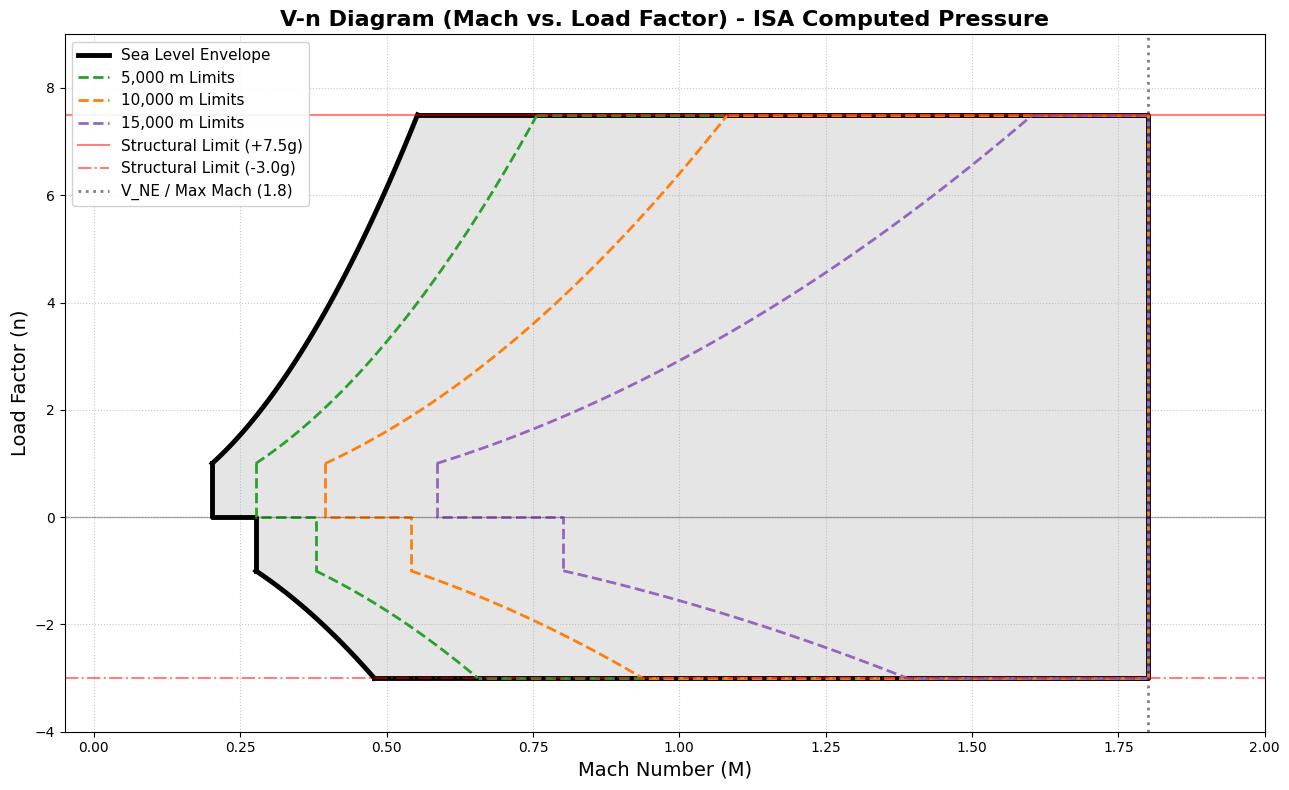

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- ISA Atmospheric Model ---
def get_isa_pressure(h):
    """Calculates atmospheric pressure (Pa) for a given altitude (m) using ISA standard."""
    p0 = 101325.0  # Sea level standard pressure (Pa)
    T0 = 288.15    # Sea level standard temperature (K)
    g = 9.80665    # Acceleration of gravity (m/s^2)
    R = 287.05     # Specific gas constant for air (J/(kg*K))
    L = -0.0065    # Temperature lapse rate in troposphere (K/m)
    
    if h <= 11000:
        # Troposphere
        return p0 * (1 + (L * h) / T0) ** (-g / (R * L))
    else:
        # Tropopause (Constant temperature layer up to 20,000m)
        T11 = T0 + L * 11000
        p11 = p0 * (1 + (L * 11000) / T0) ** (-g / (R * L))
        return p11 * np.exp(-g * (h - 11000) / (R * T11))

# --- Representative F/A-18 Hornet Data ---
W_S = 4336.0      # Wing loading (N/m^2)
CL_max = 1.5      # Maximum positive lift coefficient
CL_min = -0.8     # Maximum negative lift coefficient
n_max = 7.5       # Positive structural limit (g)
n_min = -3.0      # Negative structural limit (g)
M_max = 1.8       # Maximum Mach number limit
gamma = 1.4       # Ratio of specific heats for air

# --- Environmental Data (Dynamically Calculated) ---
target_altitudes = [0, 5000, 10000, 15000]
altitudes = {f"{alt:,} m" if alt > 0 else "Sea Level": get_isa_pressure(alt) for alt in target_altitudes}

# --- Plotting Setup ---
fig, ax = plt.subplots(figsize=(13, 8))
colors = ['black', '#2ca02c', '#ff7f0e', '#9467bd']

for (label, p), color in zip(altitudes.items(), colors):
    # 1. Calculate critical Mach numbers for this altitude
    M_B = np.sqrt((1.0 * 2 * W_S) / (gamma * p * CL_max))
    M_L = np.sqrt((1.0 * 2 * W_S) / (gamma * p * -CL_min))
    M_C = min(np.sqrt((n_max * 2 * W_S) / (gamma * p * CL_max)), M_max)
    M_K = min(np.sqrt((-n_min * 2 * W_S) / (gamma * p * -CL_min)), M_max)

    # 2. Generate curve segments
    m_BC = np.linspace(M_B, M_C, 50)
    n_BC = (gamma * p * m_BC**2 * CL_max) / (2 * W_S)
    
    m_LK = np.linspace(M_L, M_K, 50)
    n_LK = (gamma * p * m_LK**2 * CL_min) / (2 * W_S)

    # 3. Styling based on altitude
    if label == 'Sea Level':
        lw, ls = 3.5, '-'
        # # Annotate the "Step" vertices just for the primary envelope
        # pts = {'B': (M_B, 1), 'N': (M_B, 0), 'M': (M_L, 0), 'L': (M_L, -1)}
        # for name, pt in pts.items():
        #     ax.plot(pt[0], pt[1], 'ko', markersize=5, zorder=5)
        #     ax.text(pt[0] - 0.03, pt[1] + 0.3, name, fontsize=12, fontweight='bold')
    else:
        lw, ls = 2, '--'

    # 4. Draw the perimeter explicitly
    ax.plot([M_B, M_B, M_L, M_L], [1.0, 0.0, 0.0, -1.0], color=color, linestyle=ls, linewidth=lw, label=f'{label} Limits' if label != 'Sea Level' else 'Sea Level Envelope')
    ax.plot(m_BC, n_BC, color=color, linestyle=ls, linewidth=lw)
    ax.plot([M_C, M_max, M_max, M_K], [n_max, n_max, n_min, n_min], color=color, linestyle=ls, linewidth=lw)
    ax.plot(m_LK, n_LK, color=color, linestyle=ls, linewidth=lw)

    # 5. Fill the primary envelope region
    if label == 'Sea Level':
        m_fill = np.linspace(M_B, M_max, 500)
        top_fill = np.minimum((gamma * p * m_fill**2 * CL_max) / (2 * W_S), n_max)
        bot_fill = np.zeros_like(m_fill)
        for i, m in enumerate(m_fill):
            if m < M_L:
                bot_fill[i] = 0.0
            else:
                bot_fill[i] = np.maximum((gamma * p * m**2 * CL_min) / (2 * W_S), n_min)
        ax.fill_between(m_fill, bot_fill, top_fill, color='gray', alpha=0.2)

# --- Add Structural and Speed Reference Lines ---
ax.axhline(n_max, color='red', linestyle='-', linewidth=1.5, alpha=0.5, label='Structural Limit (+7.5g)')
ax.axhline(n_min, color='red', linestyle='-.', linewidth=1.5, alpha=0.5, label='Structural Limit (-3.0g)')
ax.axvline(M_max, color='black', linestyle=':', linewidth=2, alpha=0.5, label='V_NE / Max Mach (1.8)')
ax.axhline(0, color='black', linewidth=1, alpha=0.3) # 0g reference line

# --- Chart Formatting ---
ax.set_title('V-n Diagram (Mach vs. Load Factor) - ISA Computed Pressure', fontsize=16, fontweight='bold')
ax.set_xlabel('Mach Number (M)', fontsize=14)
ax.set_ylabel('Load Factor (n)', fontsize=14)
ax.set_xlim(-0.05, 2.0)
ax.set_ylim(-4.0, 9.0)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()


## Fuselage Loads and Trim Solution\n
\n
Calculates numerical integration for a balanced assembly design point.

/var/folders/tb/xvdhnp895ls5py37j6t0wy1w0000gp/T/ipykernel_23141/3148685737.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  w_fus = w_fus * (fus_mass_total / np.trapz(w_fus, x_range)) # Normalize mass
/var/folders/tb/xvdhnp895ls5py37j6t0wy1w0000gp/T/ipykernel_23141/3148685737.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mom_fus = np.trapz(w_fus * x_range, x_range)
/var/folders/tb/xvdhnp895ls5py37j6t0wy1w0000gp/T/ipykernel_23141/3148685737.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  net_inertial_mom_cg = (np.trapz(w_fus * nz * (x_range - cg_fs), x_range) +
/var/folders/tb/xvdhnp895ls5py37j6t0wy1w0000gp/T/ipykernel_23141/3148685737.py:54: DeprecationWarning: `trapz` is deprecated. Use `trapezoid

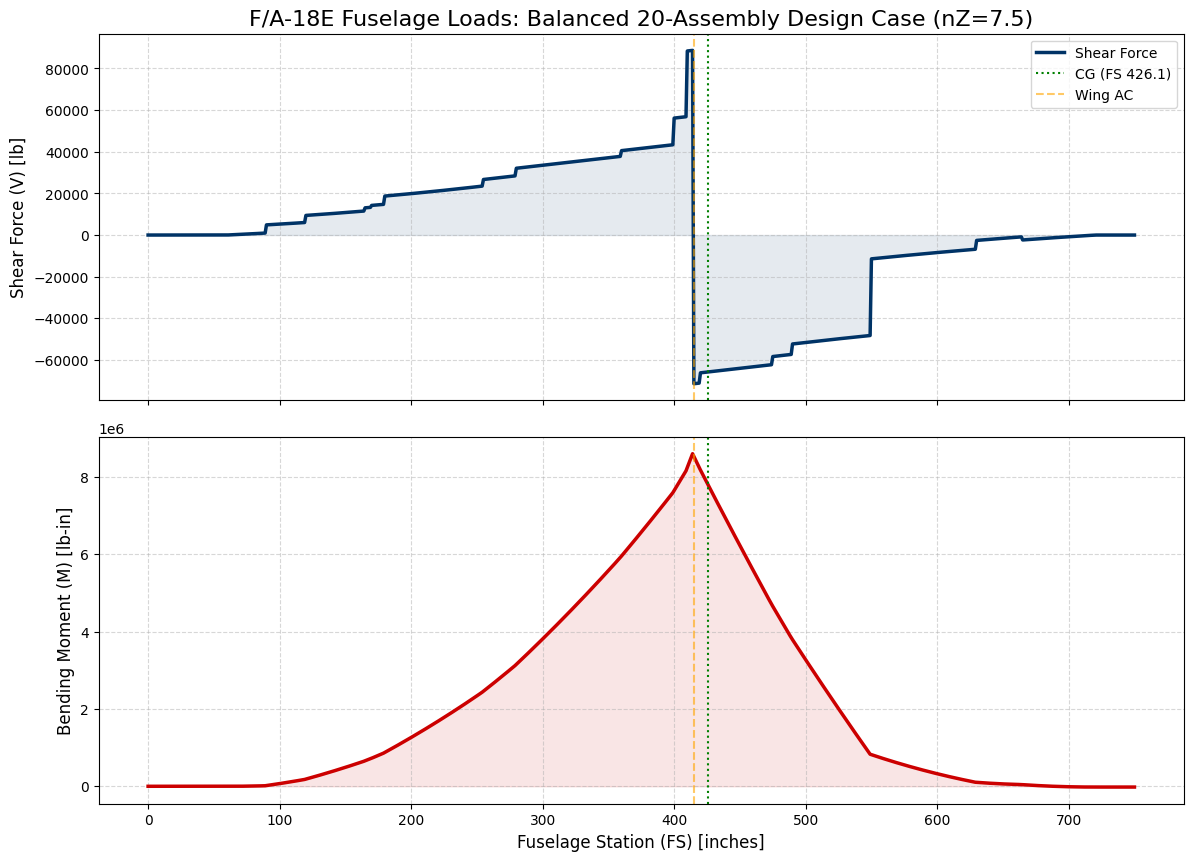

Total Design Mass: 22345 lb
Wing Lift (Lw): 160142 lb | Tail Lift (Lt): 7445 lb


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Parameter Definitions
nz = 7.5  # Load factor for a high-g maneuver
fs_start, fs_end = 60, 720  # Range of the physical fuselage shell
wing_ac, tail_ac = 415.0, 665.0  # Aerodynamic centers for lift application

# 2. Structural Distribution (Fuselage Group)
# Summing the "Shell" items from our table: 1100 + 1400 + 1600 + 1200 = 5300 lb
fus_mass_total = 5300 

def get_w_fus(x):
    """Defines the distributed weight of the fuselage shell structure."""
    if x < fs_start or x > fs_end: return 0
    # Trapezoidal distribution: Peak in center (wing carry-through), taper at ends
    if x < 250: return np.interp(x, [fs_start, 250], [6, 15])
    if x < 500: return 15.0
    return np.interp(x, [500, fs_end], [15, 8])

x_range = np.linspace(0, 750, 751)
w_fus = np.array([get_w_fus(x) for x in x_range])
w_fus = w_fus * (fus_mass_total / np.trapz(w_fus, x_range)) # Normalize mass

# 3. Systems/Component Point Masses (The remaining 16 concentrated items)
pt_masses = pd.DataFrame({
    "Name": ["Radar", "Nose Gear", "Avionics", "Displays", "Pilot/Seat", "Cannon", 
             "ECS", "LEFs", "Main Gear", "Wing", "Hydraulics", "IDECM/APU", 
             "TEFs/Ail", "Engines", "V-Tails", "H-Stabs/Hook"],
    "Mass": [520, 450, 200, 120, 525, 415, 480, 360, 1700, 4200, 650, 515, 660, 4900, 560, 790],
    "FS": [90, 120, 165, 170, 180, 255, 280, 360, 400, 410, 420, 475, 490, 550, 630, 665]
})

# 4. Global Trim Solver
total_mass = fus_mass_total + pt_masses['Mass'].sum()
mom_fus = np.trapz(w_fus * x_range, x_range)
mom_pt = (pt_masses['Mass'] * pt_masses['FS']).sum()
cg_fs = (mom_fus + mom_pt) / total_mass

# Calculate forces needed to balance the aircraft at nz
total_inertial = total_mass * nz
net_inertial_mom_cg = (np.trapz(w_fus * nz * (x_range - cg_fs), x_range) + 
                       (pt_masses['Mass'] * nz * (pt_masses['FS'] - cg_fs)).sum())

# Solver Matrix: Force Eq + Moment Eq
A = np.array([[1, 1], [(wing_ac - cg_fs), (tail_ac - cg_fs)]])
B = np.array([total_inertial, -net_inertial_mom_cg])
Lw, Lt = np.linalg.solve(A, B)

# 5. Shear (V) and Bending Moment (M) Integration
shear = np.zeros_like(x_range)
for i, x in enumerate(x_range):
    term_dist = np.trapz(w_fus[:i+1] * nz, x_range[:i+1])
    term_point = pt_masses[pt_masses['FS'] <= x]['Mass'].sum() * nz
    term_aero = (-Lw if wing_ac <= x else 0) + (-Lt if tail_ac <= x else 0)
    shear[i] = term_dist + term_point + term_aero

moment = np.cumsum(shear) # Integrate shear to find bending moment

# 6. Professional Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
plt.subplots_adjust(hspace=0.1)

# Shear Diagram
ax1.plot(x_range, shear, color='#003366', lw=2.5, label='Shear Force')
ax1.fill_between(x_range, shear, alpha=0.1, color='#003366')
ax1.set_title(f"F/A-18E Fuselage Loads: Balanced 20-Assembly Design Case (nZ={nz})", fontsize=16)
ax1.set_ylabel("Shear Force (V) [lb]", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)

# Bending Moment Diagram
ax2.plot(x_range, moment, color='#CC0000', lw=2.5, label='Bending Moment')
ax2.fill_between(x_range, moment, alpha=0.1, color='#CC0000')
ax2.set_ylabel("Bending Moment (M) [lb-in]", fontsize=12)
ax2.set_xlabel("Fuselage Station (FS) [inches]", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)

# Indicators
for ax in [ax1, ax2]:
    ax.axvline(cg_fs, color='green', linestyle=':', label=f'CG (FS {cg_fs:.1f})')
    ax.axvline(wing_ac, color='orange', linestyle='--', alpha=0.6, label='Wing AC')

ax1.legend(loc='upper right')
plt.show()

print(f"Total Design Mass: {total_mass:.0f} lb")
print(f"Wing Lift (Lw): {Lw:.0f} lb | Tail Lift (Lt): {Lt:.0f} lb")

# Multi-Spar Wing Box Analytical Model: F/A-18 Hornet (Imperial Units)
This notebook provides a structural analysis of a multi-spar wing box. It utilizes an idealized F/A-18 planform, Schrenk's approximation for aerodynamic loads, and evaluates bending and torsional shear flows mapped onto the **true airfoil contour**. Isotropic material properties (Aluminum 7075-T6) are used in US Customary units (in, lbf, psi).

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import cumulative_trapezoid

# --- Geometry Parameters (Inches) ---
b_half = 220.5        # Semi-span (in)
c_root = 157.5        # Root chord (in)
c_tip = 47.2          # Tip chord (in)
sweep_deg = 20.0      # Quarter-chord sweep (degrees)
sweep_rad = np.radians(sweep_deg)
tc_root = 0.06        # Thickness-to-chord ratio at root
tc_tip = 0.05         # Thickness-to-chord ratio at tip

front_spar_loc = 0.15 # 15% chord
rear_spar_loc = 0.65  # 65% chord

# --- Isotropic Material Properties (Aluminum 7075-T6) ---
E_al = 10.4e6         # Elastic Modulus (psi)
G_al = 3.9e6          # Shear Modulus (psi)
nu_al = 0.33          # Poisson's ratio
Fty_al = 73000.0      # Yield Strength tensile (psi)
Fsy_al = 42000.0      # Shear Yield Strength (psi)

# --- Structural Variables ---
t_skin = 0.5          # Wing skin thickness (in)
t_web = 0.3           # Spar web thickness (in)
A_cap = 3.0           # Area of a single spar cap (in^2)
L_rib = 20.0          # Estimated rib spacing (in)

# Aerodynamic Load (7.5g maneuver, ~35,000 lbf aircraft weight)
g_load = 7.5
weight = 35000 # lbf
L_total = weight * g_load / 2.0 # Lift per semi-span (lbf)

# Discretize the span
y = np.linspace(0, b_half, 100)
lam = c_tip / c_root
c_y = c_root * (1 - (1 - lam) * (y / b_half))
t_y = c_y * (tc_root - (tc_root - tc_tip) * (y / b_half))

## 2. Load Distribution (Schrenk's Approximation)
We apply Schrenk's approximation and resolve the loads perpendicular to the elastic axis to find internal shear force ($V$) and bending moment ($M$).

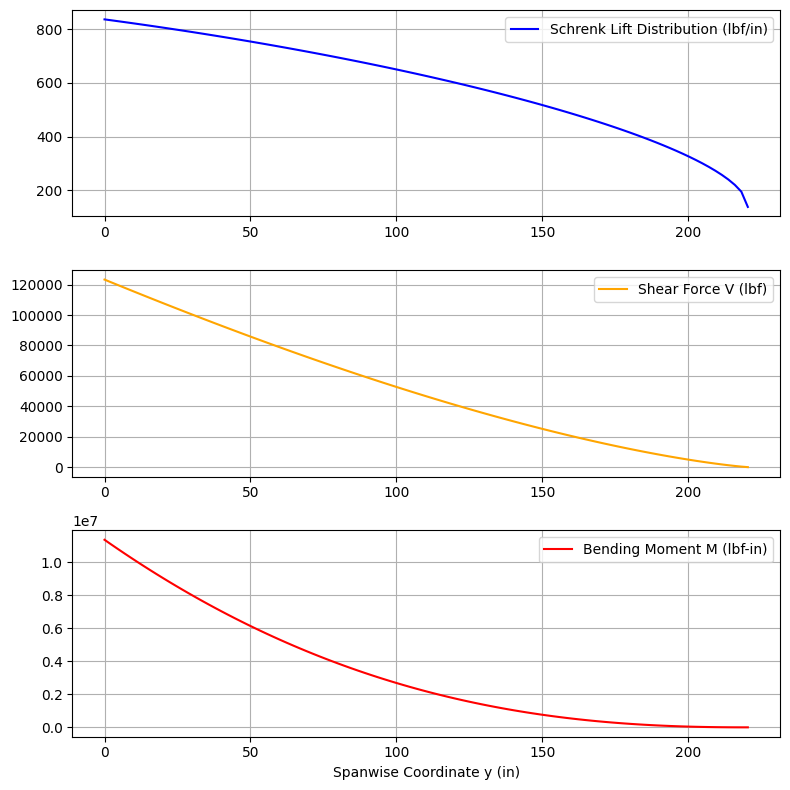

In [4]:
# Planform and Elliptical Lift
L_p = (2 * L_total / (b_half * (1 + lam))) * (1 - (1 - lam) * (y / b_half))
L_e = (4 * L_total / (np.pi * b_half)) * np.sqrt(1 - (y / b_half)**2)

L_y = 0.5 * (L_p + L_e)
q_n = L_y * np.cos(sweep_rad)

# Integrate for Shear (V) and Bending Moment (M)
q_n_rev = q_n[::-1]
y_rev = y[::-1]
V_rev = cumulative_trapezoid(q_n_rev, x=-y_rev, initial=0)
V = V_rev[::-1]
M_rev = cumulative_trapezoid(V_rev, x=-y_rev, initial=0)
M = M_rev[::-1]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 8))
ax1.plot(y, L_y, 'b-', label='Schrenk Lift Distribution (lbf/in)')
ax1.grid(True); ax1.legend()
ax2.plot(y, V, 'orange', label='Shear Force V (lbf)')
ax2.grid(True); ax2.legend()
ax3.plot(y, M, 'r-', label='Bending Moment M (lbf-in)')
ax3.set_xlabel('Spanwise Coordinate y (in)')
ax3.grid(True); ax3.legend()
plt.tight_layout(); plt.show()